In [48]:
# Clustering

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv('headlines.csv' , names = ['text'])
df.shape

(2225, 1)

In [51]:
df

,text
0,Budget to set scene for election\n \n Gordon B...
1,Army chiefs in regiments decision\n \n Militar...
2,Howard denies split over ID cards\n \n Michael...
3,Observers to monitor UK election\n \n Minister...
4,Kilroy names election seat target\n \n Ex-chat...
...,...
2220,India opens skies to competition\n \n India wi...
2221,Yukos bankruptcy 'not US matter'\n \n Russian ...
2222,Survey confirms property slowdown\n \n Governm...
2223,High fuel prices hit BA's profits\n \n British...


In [52]:
df['text'][0]

'Budget to set scene for election\n \n Gordon Brown will seek to put the economy at the centre of Labour\'s bid for a third term in power when he delivers his ninth Budget at 1230 GMT. He is expected to stress the importance of continued economic stability, with low unemployment and interest rates. The chancellor is expected to freeze petrol duty and raise the stamp duty threshold from Â£60,000. But the Conservatives and Lib Dems insist voters face higher taxes and more means-testing under Labour.\n \n Treasury officials have said there will not be a pre-election giveaway, but Mr Brown is thought to have about Â£2bn to spare.\n \n - Increase in the stamp duty threshold from Â£60,000 \n  - A freeze on petrol duty \n  - An extension of tax credit scheme for poorer families \n  - Possible help for pensioners The stamp duty threshold rise is intended to help first time buyers - a likely theme of all three of the main parties\' general election manifestos. Ten years ago, buyers had a much g

#### Data Preprocessing 

In [53]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

In [54]:
swords = stopwords.words('english')

In [55]:
wnl = WordNetLemmatizer()
wnl.lemmatize('expected' , pos = 'v')

'expect'

In [56]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

In [57]:
def lemmatize(word):
    # Extracting the pos tag of the word.
    tag = pos_tag([word])[0][1]
    # Map the pos tag to simple form like 'v' , 'n'
    if tag.startswith('V'):
        pos_type = wordnet.VERB #'v'
    elif tag.startswith('J'):
        pos_type = wordnet.ADJ #'a'
    elif tag.startswith('R'):
        pos_type = wordnet.ADV #'r'
    else:
        pos_type = wordnet.NOUN #'n'

    return wnl.lemmatize(word, pos=pos_type)

In [58]:
def clean_text(sent):
    tokens1 = word_tokenize(sent)
    tokens2 = [token for token in tokens1 if token.isalpha()]
    tokens3 = [lemmatize(token.lower()) for token in tokens2 if token.lower() not in swords]
    return tokens3
    

In [59]:
sent = 'it was expected to rain today. But it was stopped'

In [60]:
clean_text(sent)

['expect', 'rain', 'today', 'stop']

In [61]:
#### Vectorized the data

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [63]:
tfidf = TfidfVectorizer(analyzer = clean_text)

In [64]:
x_new = tfidf.fit_transform(df['text'])

In [65]:
x_new.shape

(2225, 21406)

In [66]:
from wordcloud import WordCloud

In [67]:
final_text = df['text'].apply(clean_text).sum()

In [68]:
final_text = " ".join(final_text)

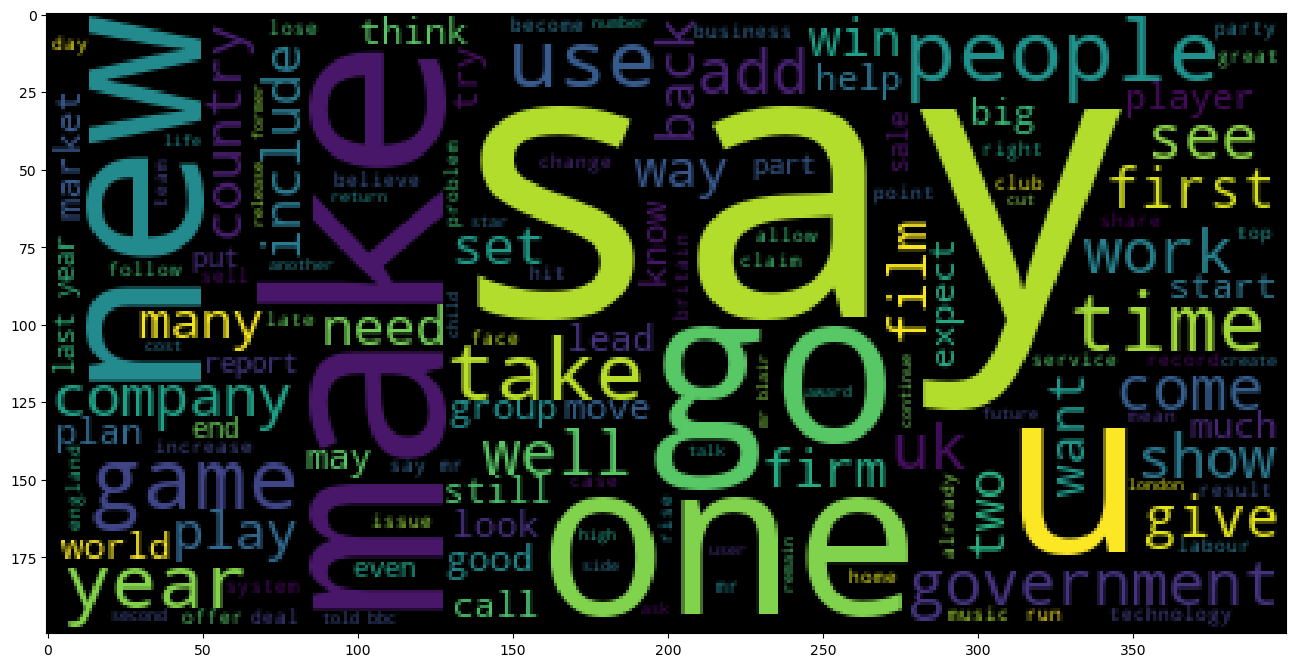

In [69]:
wcloud = WordCloud().generate(final_text)
plt.figure(figsize=(16,9))
plt.imshow(wcloud)

In [70]:
swords.extend(['say','said','saying','make','made','one','u','new','new','go','gone','went'])

In [71]:
def clean_text(sent):
    tokens1 = word_tokenize(sent)
    tokens2 = [token for token in tokens1 if token.isalpha()]
    tokens3 = [lemmatize(token.lower()) for token in tokens2 if token.lower() not in swords]
    return tokens3

In [72]:
tfidf = TfidfVectorizer(analyzer = clean_text)

In [73]:
x_new = tfidf.fit_transform(df['text'])

In [74]:
x_new.shape

(2225, 21406)

#### Identify the number of clusters

In [75]:
from sklearn.cluster import KMeans

In [93]:
km = KMeans(n_clusters=5, n_init = 'auto' , random_state=0)

In [94]:
km.fit(x_new)

KMeans(n_clusters=5, random_state=0)

In [95]:
km.inertia_

2098.2205813436262

In [96]:
sse = []
K_range = range(1,16)
for k in K_range:
    km = KMeans(n_clusters = k, n_init = 'auto')
    km.fit(x_new)
    sse.append(km.inertia_)

In [97]:
sse

[2163.7187932929055,
 2144.897240715012,
 2133.384435206917,
 2118.991660218583,
 2101.870388513832,
 2094.4814841656057,
 2084.538948362628,
 2074.913851851909,
 2067.3974833845705,
 2061.860857423638,
 2050.906763985894,
 2053.135282580156,
 2048.7383897715604,
 2032.8671644254202,
 2021.4363641500054]

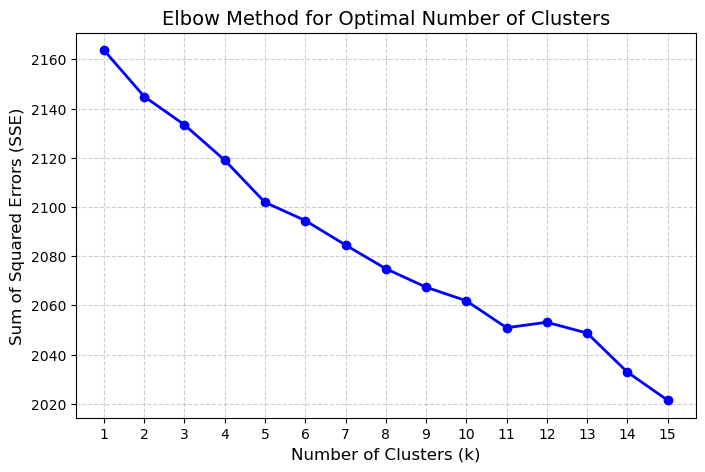

In [98]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, sse,marker='o', linestyle='-', color='b', linewidth=2)

# Axis titles and labels
plt.title('Elbow Method for Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Sum of Squared Errors (SSE)', fontsize=12)

# Ensure every cluster number is shown on the x-axis
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

In [99]:
pip install kneed

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [100]:
from kneed import KneeLocator

In [101]:
kl= KneeLocator(range(1,16),sse , curve='convex' , direction='decreasing')
kl.elbow

5

#### Create the CLusters

In [155]:
km = KMeans(n_clusters=5 , n_init='auto' , random_state=0)

In [156]:
labels = km.fit_predict(x_new)

In [157]:
labels

array([4, 3, 4, ..., 3, 3, 3])

In [158]:
zero = df['text'][labels == 0]
one = df['text'][labels == 1]
two = df['text'][labels == 2]
three = df['text'][labels == 3]
four = df['text'][labels == 4]


In [159]:
zero.shape , one.shape , two.shape , three.shape , four.shape  

((378,), (353,), (519,), (691,), (284,))

In [160]:
zero = " ".join(zero.apply(clean_text).sum())

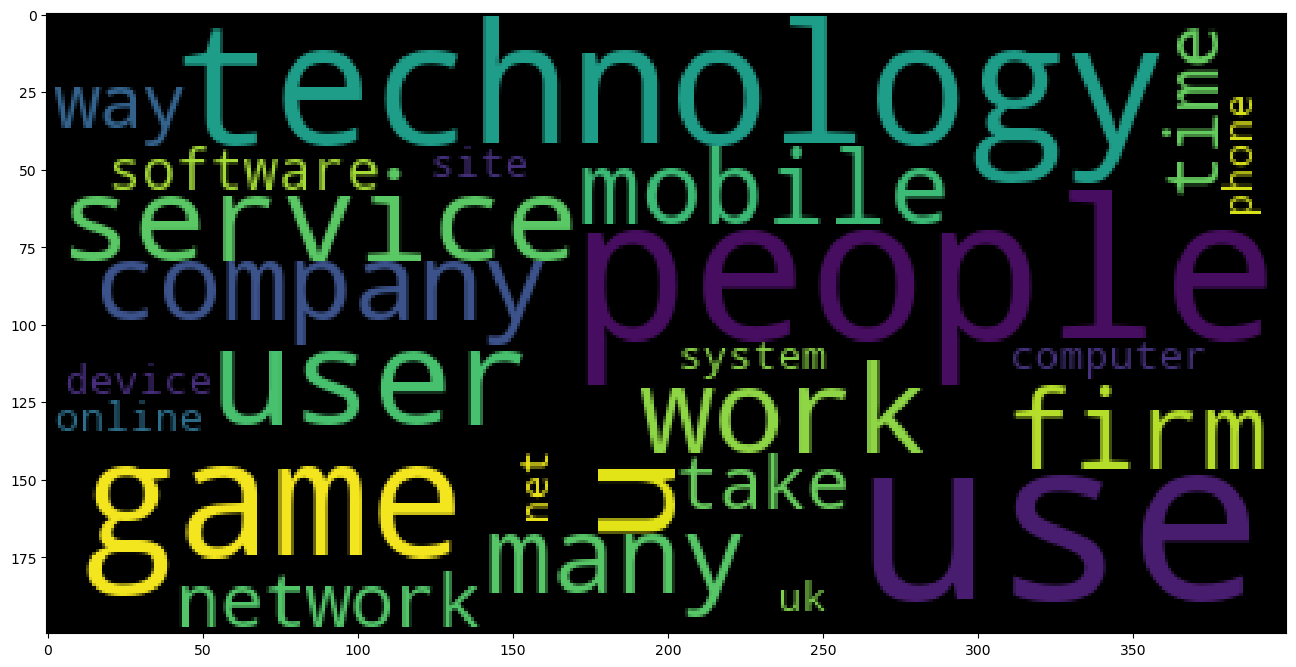

In [161]:
# Technology News
zero_wcloud = WordCloud(max_words=25).generate(zero)
plt.figure(figsize=(16,9))
plt.imshow(zero_wcloud)

In [162]:
zero_wcloud.words_

{'use': 1.0,
 'people': 0.7277486910994765,
 'technology': 0.675392670157068,
 'game': 0.6230366492146597,
 'u': 0.4908376963350785,
 'user': 0.4581151832460733,
 'service': 0.43324607329842935,
 'work': 0.4214659685863874,
 'company': 0.40575916230366493,
 'many': 0.4005235602094241,
 'firm': 0.39659685863874344,
 'mobile': 0.39397905759162305,
 'network': 0.3769633507853403,
 'way': 0.36780104712041883,
 'take': 0.36518324607329844,
 'time': 0.3586387434554974,
 'software': 0.3586387434554974,
 'computer': 0.35732984293193715,
 'uk': 0.35732984293193715,
 'net': 0.34554973821989526,
 'site': 0.3390052356020942,
 'system': 0.32329842931937175,
 'phone': 0.3193717277486911,
 'online': 0.31413612565445026,
 'device': 0.31151832460732987}

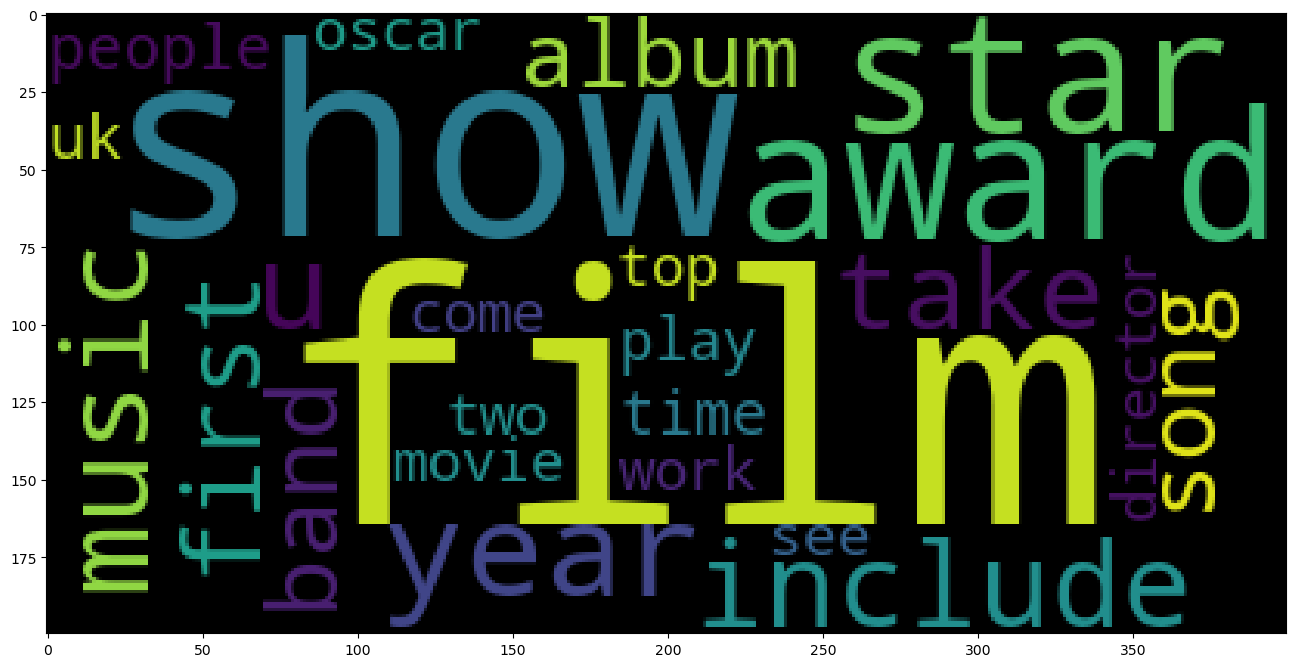

In [163]:
# Entertainment News
one = " ".join(one.apply(clean_text).sum())
one_wcloud = WordCloud(max_words=25).generate(one)
plt.figure(figsize=(16,9))
plt.imshow(one_wcloud)

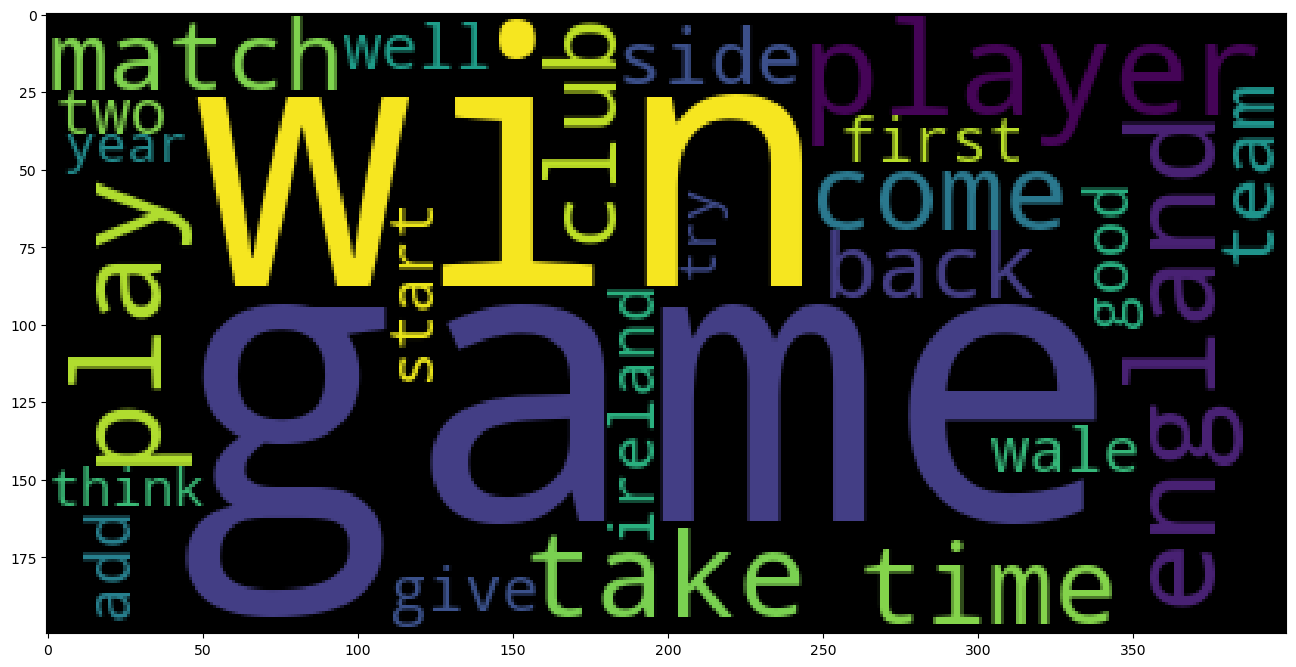

In [164]:
# Sports News
two = " ".join(two.apply(clean_text).sum())
two_wcloud = WordCloud(max_words=25).generate(two)
plt.figure(figsize=(16,9))
plt.imshow(two_wcloud)

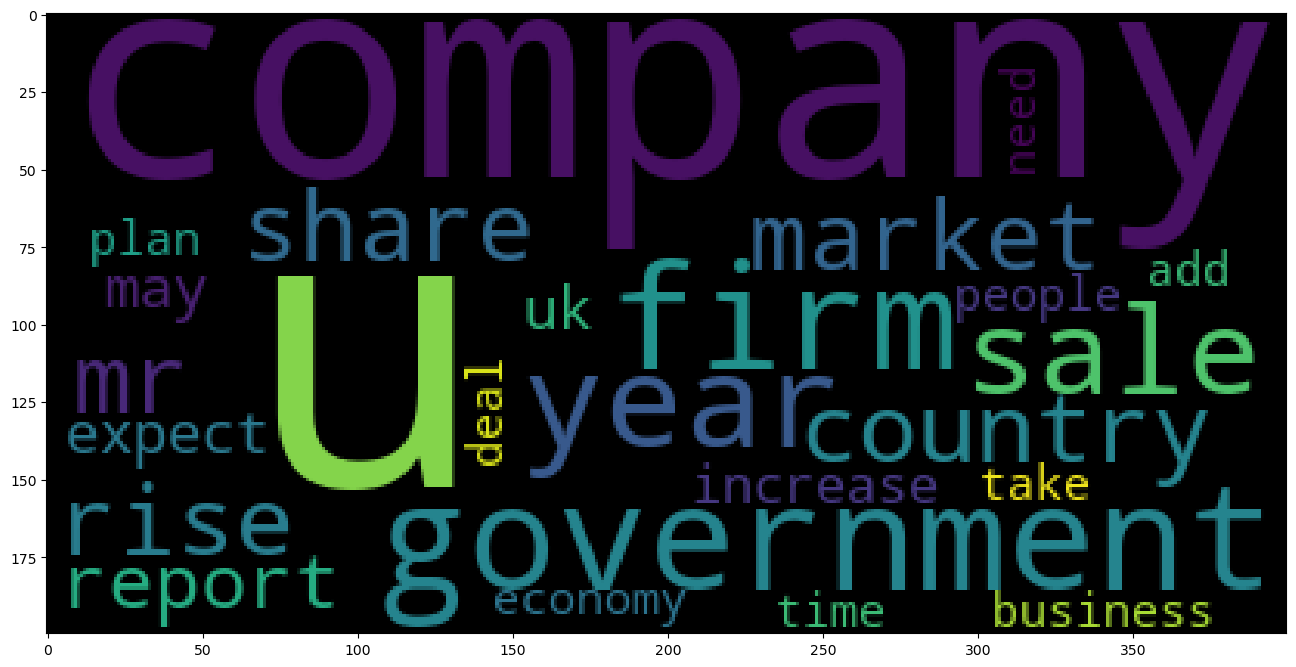

In [165]:
# Finnacial News
three = " ".join(three.apply(clean_text).sum())
three_wcloud = WordCloud(max_words=25).generate(three)
plt.figure(figsize=(16,9))
plt.imshow(three_wcloud)

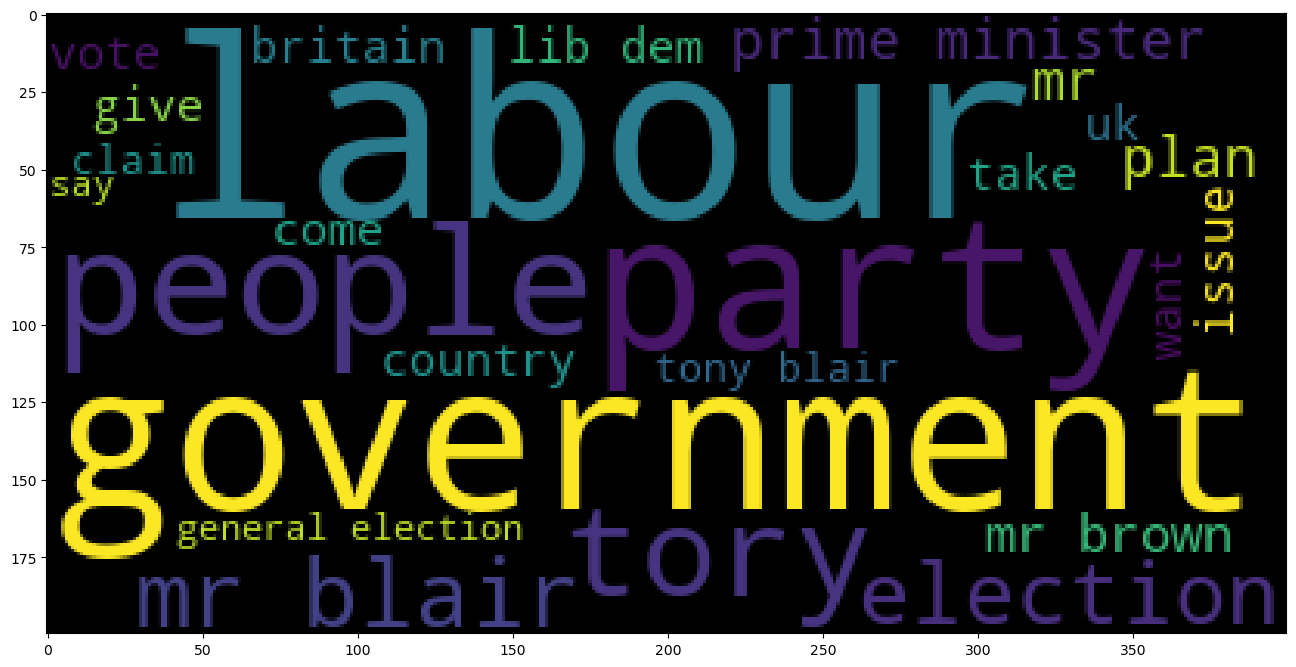

In [166]:
# Political News
four = " ".join(four.apply(clean_text).sum())
four_wcloud = WordCloud(max_words=25).generate(four)
plt.figure(figsize=(16,9))
plt.imshow(four_wcloud)

In [171]:
new_text = """FIFA World Cup 2026: In 10 days, the FIFA World Cup will open arms to its biggest edition yet with 48 teams gearing up for glory across month-long action in the United States, Mexico and Canada.
The teams have begun their preparations in their designated Team Base Training (TNT) camps across the three nations with a bunch of friendly matches left to firm up their formations and tactics heading into league-stage action.
ALSO READ | FIFA World Cup 2026 squads: Final player lists and rosters of all 48 teams
Here’s a look at the schedule of the top teams ahead of their group-stage matches.
France (FIFA Ranking 1)
Friendlies: Colombia 1-3 France (May 30), France v Ivory Coast (June 5) and France v Northern Ireland (June 9
France FIFA WC schedule (Group I): France v Senegal (June 17), France v Iraq (June 23), France v Norway (June 27)
Spain (FIFA Ranking: 2)
Friendlies: Spain vs Iraq (June 5), Spain vs Peru (June 9)
Spain FIFA WC schedule (Group H): Spain v Cape Verde (June 15), Spain v Saudi Arabia (June 21), Spain v Uruguay (June 27)
Argentina (FIFA Ranking: 3)
Friendlies: Argentina v Honduras (June 7), Argentina vs Iceland (June 10)
Argentina FIFA WC schedule (Group J): Argentina vs Algeria (June 17), Argentina vs Austria (June 22), Argentina vs Jordan (June 28)
England (FIFA Ranking: 4)
Friendlies: England vs New Zealand (June 7), England vs Costa Rica (June 11)
England FIFA WC schedule (Group L): England v Croatia (June 18), England v Ghana (June 24), England v Panama (June 28).
Portugal (FIFA Ranking: 5)
Friendlies: Portugal vs Chile (June 6), Portugal vs Nigeria (June 11)
Portugal FIFA WC schedule (Group K): Portugal vs DR Congo (June 17), Portugal vs Uzbekistan (June 23), Portugal vs Colombia (June 28).
Brazil (FIFA Ranking: 6
Friendlies: Brazil 6-2 Panama (June 1), Brazil v Egypt (June 7)
Brazil FIFA WC schedule (Group C): Brazil v Morocco (June 14), Brazil vs Haiti (June 20), Brazil vs Scotland (June 25)
Netherlands (FIFA Ranking: 7)
Friendlies: Netherlands vs Algeria (June 4), Netherlands vs Uzbekistan (June 9)
Netherlands FIFA WC schedule (Group F): Netherlands vs Japan (June 15), Netherlands vs Sweden (June 20), Netherlands vs Tunisia (June 26)
Germany (FIFA Ranking: 10)
Friendlies: Germany 4-0 Finland (June 1), Germany vs USA (June 7)
Germany FIFA WC schedule (Group E): Germany v Curacao (June 14), Germany vs Ivory Coast (June 21), Germany vs Ecuador (June 26)."""

In [188]:
cleaned_words = clean_text(new_text)

In [186]:
tfidf = TfidfVectorizer(analyzer=clean_text)

In [190]:
vectorized_text = tfidf.transform([new_text])

NotFittedError: The TF-IDF vectorizer is not fitted

In [191]:
# 5. Predict the cluster
predicted_cluster = km.predict(vectorized_text)
print(f"The predicted cluster for the new text is: Cluster {predicted_cluster[0]}")

NameError: name 'vectorized_text' is not defined

In [192]:
x_vectorized = tfidf.fit_transform(df['cleaned_words'])

KeyError: 'cleaned_words'

In [193]:
km.fit(x_vectorized)

NameError: name 'x_vectorized' is not defined